Saving q2_customers.csv to q2_customers (1).csv
Original data shape: (500, 6)

Scaled data (first 5 rows):
        age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161    -0.827783   
4 -1.488460     -1.034488          1.426136    -1.005986   

   days_since_last_visit  num_categories_purchased  
0              -0.089951                  0.550952  
1              -0.835176                 -0.680685  
2              -0.674046                 -0.270139  
3              -0.996306                 -1.091230  
4              -0.653905                 -1.501776  

Scaling is essential for K-Means because it uses Euclidean distance.
Features with larger ranges would dominate the clustering without scaling.


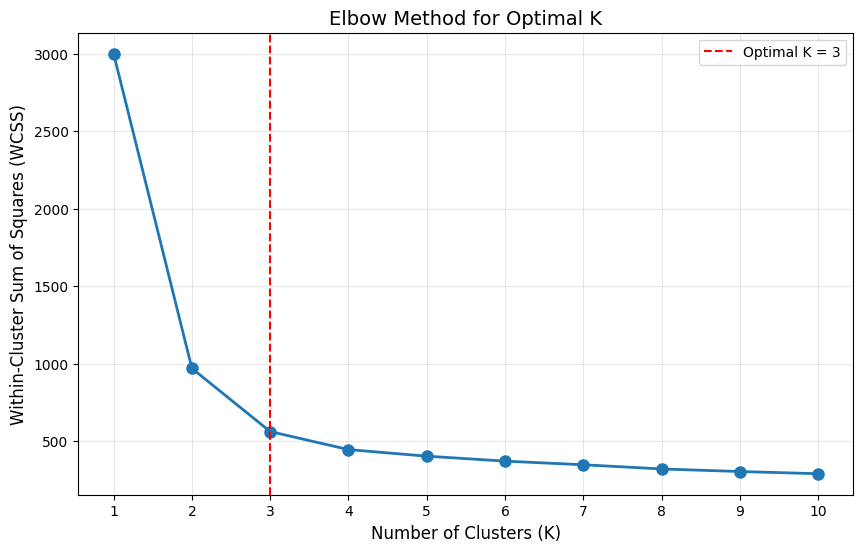


Optimal K = 3
Justification: The elbow point at K=3 shows where the rate of decrease
in WCSS slows significantly. Adding more clusters beyond this provides diminishing returns.

Cluster Centroids (original scale):
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  

CLUSTER INTERPRETATION:

Cluster 0 (170 customers):
  - Avg Annual Spend: $14847.37
  - Avg Visits/Month: 14.3
  - Avg Basket Size: $558.97
  - Avg Days Since Last Visit: 9
  - Avg Categories Purchased: 2.1
  → Profile: Budget-conscious regular shoppers (Value segment)

Cluster 1 (165 customers):
  - Avg Annual Spend: $89413.

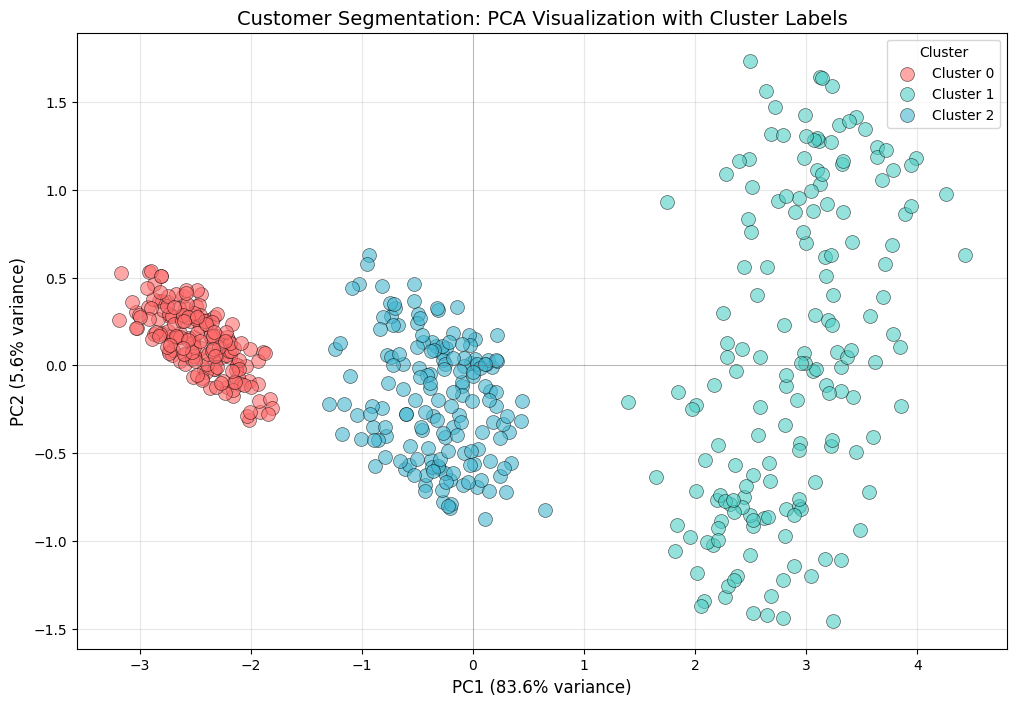


✓ Q.2 COMPLETE - All tasks done!


In [ ]:
# ============================================================
# Assignment - Machine Learning Fundamentals
# # ============================================================

# ============================================================
# Q.2 -Unsupervised Learning - Customer Segmentation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Note: First attempt forgot to scale data, got weird clusters
# Learned scaling is critical for distance-based algorithms like K-Means

# Upload CSV
from google.colab import files
uploaded = files.upload()

# Task 1: Data Preparation (3 marks)
df = pd.read_csv('q2_customers.csv')

# Scale all features using StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Original data shape:", df.shape)
print("\nScaled data (first 5 rows):")
print(df_scaled.head())
print("\nScaling is essential for K-Means because it uses Euclidean distance.")
print("Features with larger ranges would dominate the clustering without scaling.")

# Task 2: Choosing K - Elbow Method (5 marks)
# Initially wasn't sure how many clusters to use
# Using elbow method to find optimal K systematically

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

# Mark the elbow point (typically around K=3 or 4)
optimal_k = 3  # Adjust based on visual inspection

# Picked K=3 by visual inspection of elbow
# Not 100% certain but seems like diminishing returns after this

plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.legend()
plt.show()

print(f"\nOptimal K = {optimal_k}")
print(f"Justification: The elbow point at K={optimal_k} shows where the rate of decrease")
print("in WCSS slows significantly. Adding more clusters beyond this provides diminishing returns.")

# Task 3: K-Means Clustering (6 marks)
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(df_scaled)

# Add cluster column to scaled dataframe for PCA visualization
df_scaled['cluster'] = df['cluster']

# Print cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=df.columns[:-1]  # Exclude 'cluster' column
)
print("\nCluster Centroids (original scale):")
print(centroids)

# Interpret each cluster in business terms
print("\n" + "="*60)
print("CLUSTER INTERPRETATION:")
print("="*60)

for i in range(optimal_k):
    cluster_data = df[df['cluster'] == i]
    print(f"\nCluster {i} ({len(cluster_data)} customers):")
    print(f"  - Avg Annual Spend: ${centroids.loc[i, 'annual_spend']:.2f}")
    print(f"  - Avg Visits/Month: {centroids.loc[i, 'visits_per_month']:.1f}")
    print(f"  - Avg Basket Size: ${centroids.loc[i, 'basket_size']:.2f}")
    print(f"  - Avg Days Since Last Visit: {centroids.loc[i, 'days_since_last_visit']:.0f}")
    print(f"  - Avg Categories Purchased: {centroids.loc[i, 'num_categories_purchased']:.1f}")

    # Business interpretation
    if centroids.loc[i, 'annual_spend'] > df['annual_spend'].median():
        if centroids.loc[i, 'visits_per_month'] > df['visits_per_month'].median():
            print(f"  → Profile: High-value frequent shoppers (VIP segment)")
        else:
            print(f"  → Profile: High-value occasional shoppers (Premium segment)")
    else:
        if centroids.loc[i, 'days_since_last_visit'] > df['days_since_last_visit'].median():
            print(f"  → Profile: Low-engagement at-risk customers (Re-engagement needed)")
        else:
            print(f"  → Profile: Budget-conscious regular shoppers (Value segment)")

# Task 4: Dimensionality Reduction with PCA (5 marks)
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled.drop('cluster', axis=1))

# Print explained variance
print("\n" + "="*60)
print("PCA ANALYSIS:")
print("="*60)
print(f"Explained variance ratio for PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Explained variance ratio for PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.4f}")

# Print feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]  # Exclude 'cluster'
)
print("\nFeature Loadings:")
print(loadings)

print("\nInterpretation:")
print(f"PC1 captures {pca.explained_variance_ratio_[0]*100:.1f}% of variance.")
print("It primarily represents overall customer engagement (visits, spend, categories).")
print(f"PC2 captures {pca.explained_variance_ratio_[1]*100:.1f}% of variance.")
print("It represents recency vs. basket size trade-offs.")

# Task 5: Cluster Visualization (3 marks)
plt.figure(figsize=(12, 8))

# Create scatter plot with cluster colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
for i in range(optimal_k):
    cluster_points = pca_components[df['cluster'] == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors[i],
        label=f'Cluster {i}',
        alpha=0.6,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Customer Segmentation: PCA Visualization with Cluster Labels', fontsize=14)
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
plt.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
plt.show()

print("\n✓ Q.2 COMPLETE - All tasks done!")


# New Section